### Epidemic modeling on Sparse GPS Trajectories

This notebook contains the functions employed for processing the GPS mobility trajectories and generating the experimental data.

Note that the mobility data is not publicly available. 


### 0. Libraries 

ERROR: Could not find a version that satisfies the requirement skmob (from versions: none)
ERROR: No matching distribution found for skmob


In [1]:
#!pip install --upgrade pip

#pickle for loading some dataframes
import inspect
import pickle
import glob

#scikit mobility for preprocessing of mobility trajectories
#import skmob 

import importlib
from Modules import analysis, config
# reload modules
importlib.reload(analysis)
importlib.reload(config)

# refresh namespace
from Modules.analysis import *
from Modules import config

### 1. Trajectory Preprocessing

In [ ]:
analysis.preprocess_GPS_mobility_trajectory

Signature: analysis.preprocess_GPS_mobility_trajectory(traj, tz=None)
Source:   
def preprocess_GPS_mobility_trajectory(traj, 
                                       tz = None):
    """
    INPUT: 
    > traj : dataframe for a single individual GPS trajectory 
        contains columns ['id', 'time_utc', 'lat', 'lon'] 
    > tz : timezone
    
    Preprocess GPS trajectory:
    - build TrajDataFrame
    - filter unrealistic speeds (max speed 100kmh)
    - convert timezone (optional)
    - downsample to 1-minute resolution
    """

    # Build TrajDataFrame (WGS84)
    traj_df = skmob.TrajDataFrame(
        traj.rename(columns={'lon': 'lng', 'time_utc': 'datetime'}),
        latitude='lat',
        longitude='lng',
        datetime='datetime',
        timestamp=True
    )

    #Remove speeds > 100 km/h
    traj_df = skmob.preprocessing.filtering.filter(traj_df, 
                                                   max_speed_kmh = 100)
    traj_df.rename(columns = {'lng':'lat', 
           

In [ ]:
#CODE TESTING
path = '/home/fedde/work/Project_Penn/TMP/f_001_D1_samples_original/'
traj = pd.read_csv(f'{path}1.csv', index_col =0)
traj.columns = ['id', 'time_utc', 'lat', 'lon', 'accuracy'] 
traj['_datetime'] = pd.to_datetime(traj['time_utc'], unit = 's', utc = True)
traj.head(2)

In [ ]:
traj_df = analysis.preprocess_GPS_mobility_trajectory(traj, 
                                                      tz = 'Europe/Copenhagen')

traj_df.head(2)

In [ ]:
path = 'Pipeline_output_DTU/01_trajectories_preprocessed/'
traj_sample = pd.read_csv(path + '1.csv')
traj_sample.head(2)

In [ ]:
traj_sample['datetime'] = pd.to_datetime(traj_sample['datetime'], utc=True).dt.tz_convert('Europe/Copenhagen').dt.tz_localize(None)

In [ ]:
traj_sample.head(2)

### 2. Sequences of hourly record indicators

In [ ]:
'''
INPUT traj_sample dataframe 
Consists of the GPS location trajectories of the students in the DTU Campus data
it contains columns ['id', 'datetime', 'lat', 'lng'] 

OUTPUT df_sequence dataframe
has as columns the sequence of hours in the study period
has MultiIndex (id, weekstep_index) described in collect_sequences doc-string
    
The dataset is employied in the pipeline to:
    > Select complete trajectories in the study period (weekstep_index = 0)
    > Sample aligned sequences for sparsification of the complete trajectories.
'''

analysis.collect_sequences??

In [25]:
#Study-period for the selection of the complete trajectories for doing epidemic modeling
#from 2014 Feb 2 to March 7 (included) 
Study_period = [dt.datetime(2014,2,8), 
                dt.datetime(2014,3,7)]

#Time-range for the selection of the sparse trajectories for sparsification
Time_range = [dt.datetime(2014,2,1), 
              dt.datetime(2015,2,1)]

#[0] import location trajectories of all the users
DICT_dtypes = {'user_id' : 'int32', 
               'datetime' : 'string'}

traj_sample = read_folder_files(path, 
                                Cols_select = ['user_id', 'datetime'],
                                dtype = DICT_dtypes, 
                                FILES_select = os.listdir(path)[:4])

traj_sample['datetime'] = pd.to_datetime(traj_sample['datetime'], utc = True).dt.tz_localize(None)

df_sequences = collect_sequences(traj_sample, 
                                 Study_period, 
                                 Time_range)

df_sequences.head(2)

NameError: name 'path' is not defined

In [26]:
#import the hourly record indicator
df_hri = pd.read_csv('Pipeline_output_SYNTH/02_df_hourly_record_indicator.csv')
df_hri = df_hri.set_index(['user_id', 'weekstep_index'])
df_hri = sort_df_rows(df_hri)

#get out users with less than 1000 records
Cov = df_hri.sum(axis=1)/df_hri.shape[1] 
df_hri['coverage'] = Cov
df_hri = df_hri.sort_values(by = 'coverage')
df_hri = df_hri.iloc[:-1600]

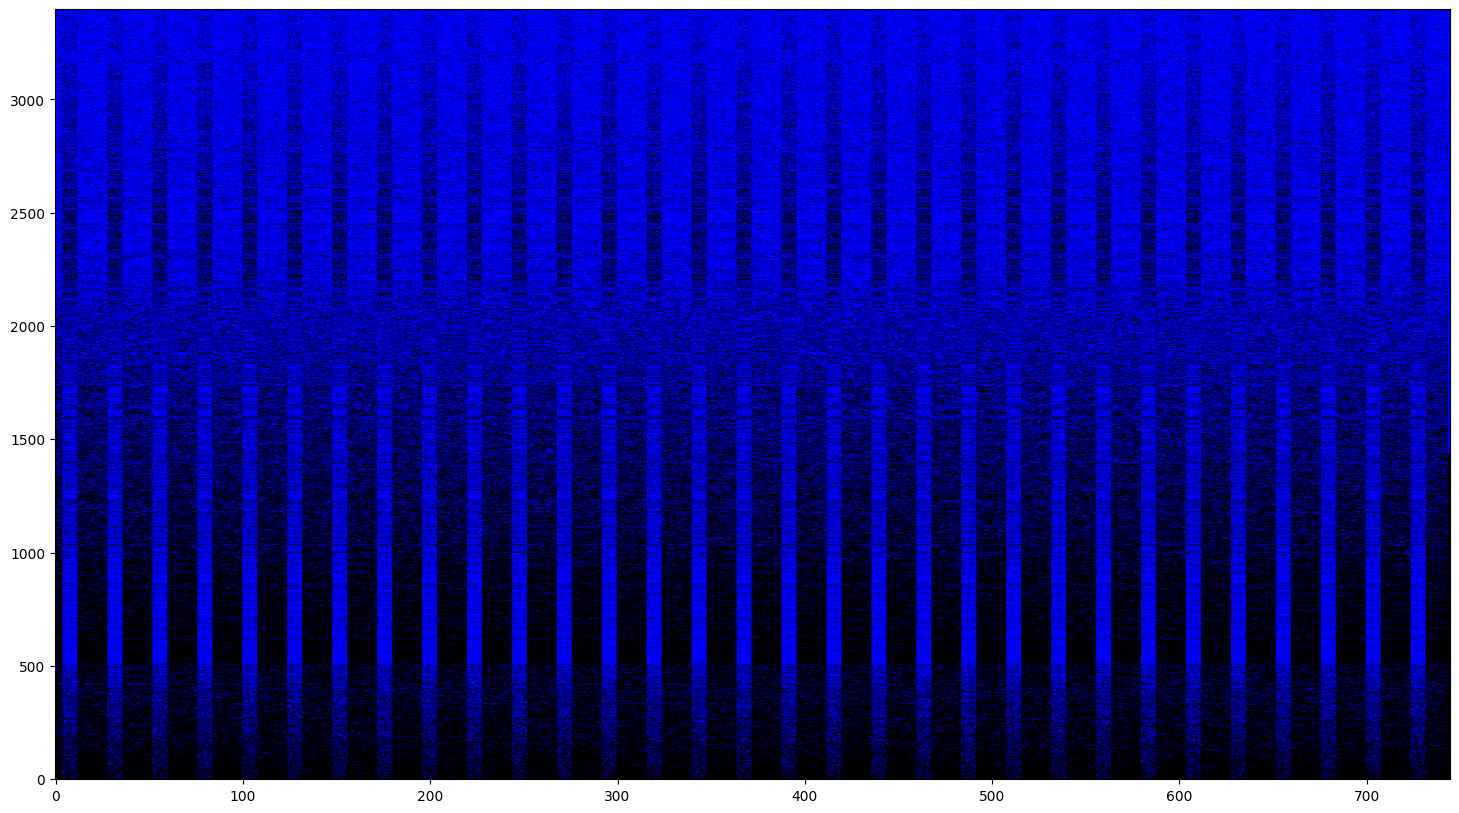

In [27]:
fig, ax = plt.subplots(figsize = (18,10))
hri = df_hri.values
visual_imshow(ax, 
              hri, 
              ['black','blue'])

(array([115., 145., 151., 570., 373., 290., 308., 401., 579., 466.]),
 array([0.05107527, 0.13629032, 0.22150538, 0.30672043, 0.39193548,
        0.47715054, 0.56236559, 0.64758065, 0.7327957 , 0.81801075,
        0.90322581]),
 <BarContainer object of 10 artists>)

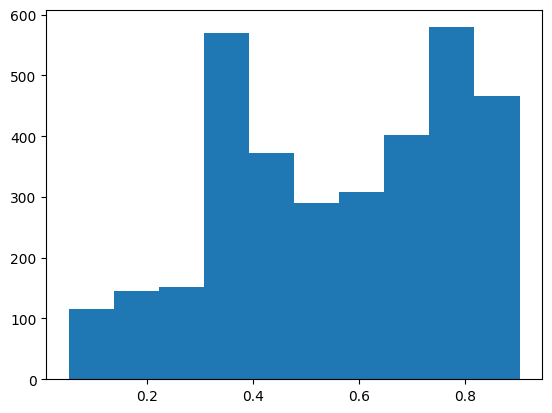

In [28]:
plt.hist(df_hri.sum(axis=1)/df_hri.shape[1])

In [24]:
traj = pd.read_csv('Pipeline_output_SYNTH/01_trajectories_preprocessed/1.csv')
traj['datetime'] = pd.to_datetime(traj['datetime'],
                                  utc=True).dt.tz_localize(None)
traj

,x,y,datetime,timestamp,user_id,lon,lat
0,202.500000,17.500000,2025-01-01 05:02:00,1735707720,1,-75.170192,39.933115
1,202.460908,17.331815,2025-01-01 05:10:00,1735708200,1,-75.170197,39.933098
2,202.460908,17.331815,2025-01-01 05:14:00,1735708440,1,-75.170197,39.933098
3,202.543675,17.934199,2025-01-01 05:51:00,1735710660,1,-75.170186,39.933160
4,202.284422,17.182546,2025-01-01 06:40:00,1735713600,1,-75.170221,39.933082
...,...,...,...,...,...,...,...
8037,202.126289,17.513638,2025-03-01 03:58:00,1740801480,1,-75.170242,39.933116
8038,202.326548,17.775374,2025-03-01 03:59:00,1740801540,1,-75.170215,39.933144
8039,202.108393,17.849187,2025-03-01 04:19:00,1740802740,1,-75.170245,39.933151
8040,202.108393,17.849187,2025-03-01 04:31:00,1740803460,1,-75.170245,39.933151


In [ ]:
df_hri = df_hri.set_index(['user_id','weekstep_index'])

#consider the time-range (weekstep_index ==0)
df_hri_tr = df_hri[df_hri.index.get_level_values('weekstep_index') == 0]

#condition for completeness over the time-range (less than 5% of missing hours)
bool_complete = df_hri_tr.sum(axis=1)/df_hri_tr.shape[1] >=0.95
USERS_complete = df_hri_tr.index.get_level_values('user_id')[bool_complete]
USERS_complete = np.sort(list(USERS_complete))

In [ ]:
len(USERS_complete)

### 3. Stop detection

In [ ]:
analysis.lachesis??

In [ ]:
#CODE TESTING
path = 'Pipeline_output_DTU/01_trajectories_preprocessed/'

DICT_dtypes = {'id':'int32', 
               'datetime':'string', 
               'lat': 'float32',
               'lon': 'float32'}

traj = pd.read_csv(path + '0.csv', 
                   usecols = ['id','datetime','lat','lng'],
                   dtype = DICT_dtypes)
traj.head(2)

In [ ]:
stays = lachesis(traj)
stays.head(2)

### 4. Contact estimation

In [ ]:
analysis.estimate_contacts??

In [ ]:
#CODE TESTING
PATH_save = '/home/fedde/work/Project_Penn/TMP/f_007_D1_lachesis_stops_AND_loc-1hdi/'
S = (10,360,50)
dur_min, dt_max, delta_roam = S  
str_lach  = f'mintime_{dur_min}_maxdtime_{dt_max}_maxdiam_{delta_roam}'
df_stops = pd.read_csv(PATH_save + 'df_stops_' + str_lach + '.csv',
                       index_col = 0, 
                       parse_dates = ['start_time', 'end_time'])

In [ ]:
df_stops.head(2)

In [ ]:
#path of stop tables
FOLD_save = config.FOLD_DTU
path_stays = f'{FOLD_save}03_stop_tables/'
files = glob.glob(f'{path_stays}*.csv')
df = pd.concat([pd.read_csv(f, index_col =0).assign(id=f.split('/')[-1].replace('.csv', '')) for f in files])#, ignore_index=True)
df.head(2)

In [ ]:
df_contacts = estimate_contacts(df_stops, 
                                ghr = 8, 
                                time_step = '1hour',
                                Date_range = [dt.datetime(2014,2,11), dt.datetime(2014,2,12)]) 
df_contacts.head(2)

In [ ]:
df_contacts = estimate_contacts(df_stops, 
                                ghr = 8, 
                                time_step = '1minute',
                                Date_range = [dt.datetime(2014,2,11), dt.datetime(2014,2,12)]) 
df_contacts.head(2)

### 5. Ground truth epidemic modeling outcomes 

In [2]:
analysis.epidemic_modeling??

Signature:
analysis.epidemic_modeling(
    df_contacts,
    USERS_select,
    dict_epid_pars,
    Date_range,
    N_iter,
)
Docstring:
INPUT
df_contacts  : df with columns ['u1', 'u2', 'date_hour', 'n_minutes']
USERS_select : list of unique users in the contact dataframe
dict_epid_pars : dict with values:
    - beta : probability of infection given 1-minute contact
    - gamma : probability of recovery over 1 day
    - seed size : number of initial infected of the SIR model
Date_range : ordered list of consecutive days of the simulation
N_iter: number of iterations of the epidemic simulation 

OUTPUT
[1] epid_curves 
    array of shape (N_iter, #simulation days, 2)
        epid_curves[i] has as columns the count of Susceptibles and Infected
        
[2] epid_metrics (computed metrics from epid curves)
    array of shape (N_iter, 5)
Source:   
def epidemic_modeling(df_contacts, 
                      USERS_select, 
                      dict_epid_pars,
                      Date_range,


In [3]:
#import the ground truth contacts
files = glob.glob('Pipeline_output_DTU/04_contacts/*.csv')
df_contacts_gt = pd.concat([pd.read_csv(f, index_col = 0) for f in files])
df_contacts_gt.head(2)

,u1,u2,date_hour,n_minutes
0,0,165,2014-02-09 11:00:00,25
1,0,165,2014-02-09 12:00:00,48


In [ ]:
#consider study period for epidemic modeling (starting on Monday)
Study_period_em = [dt.datetime(2014,2,10), dt.datetime(2014,3,7)]

#[1.1] Epidemic parameters
groundtruth_pars = {'beta': 0.000845, #probability of infection given 1-minute contact
                    'gamma': 0.268,   #probability of recovery over 1 day
                    'n_init': 3}      # seed size of the SIR model

N_iter = 5000 # number of iterations of the epidemic simulation
epid_curves, epid_metrics = epidemic_modeling(df_contacts_gt, 
                                              USERS_select, 
                                              groundtruth_pars,
                                              Study_period_em,
                                              N_iter)

### 6. Sparsification and Biased contacts estimation

This code segement applies sequentially stop detection and contact estimation on the sample of sparsified complete trajectories.

#### 6.1 Creation of the hourly record indicator mask for sparsification 

In [9]:
#[1] import sequence indicator
FOLD_save = config.FOLD_DTU
path_seq = f'{FOLD_save}02_df_hourly_record_indicator.csv'

df_seq = pd.read_csv(path_seq).set_index(['user_id','weekstep_index'])
df_seq.head(2)

,,2014-02-08 00:00:00,2014-02-08 01:00:00,2014-02-08 02:00:00,2014-02-08 03:00:00,2014-02-08 04:00:00,2014-02-08 05:00:00,2014-02-08 06:00:00,2014-02-08 07:00:00,2014-02-08 08:00:00,2014-02-08 09:00:00,...,2014-03-07 14:00:00,2014-03-07 15:00:00,2014-03-07 16:00:00,2014-03-07 17:00:00,2014-03-07 18:00:00,2014-03-07 19:00:00,2014-03-07 20:00:00,2014-03-07 21:00:00,2014-03-07 22:00:00,2014-03-07 23:00:00
user_id,weekstep_index,,,,,,,,,,,,,,,,,,,,,
9,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
83,-1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [10]:
#remove sequences which have gaps larger than 1 week
df_seq = filter_sequences(df_seq)

#[2] select the complete users
df_seq_w0 = df_seq[df_seq.index.get_level_values("weekstep_index") == 0]
df_seq_complete = df_seq_w0[df_seq_w0.mean(axis=1) >= 0.95]

df_seq = df_seq.droplevel('weekstep_index')
df_seq_complete = df_seq_complete.droplevel('weekstep_index')

__Instance of data-driven sparsification for a specific sparsity level__

Text(0.5, 1.1, 'Data-driven sparsification')

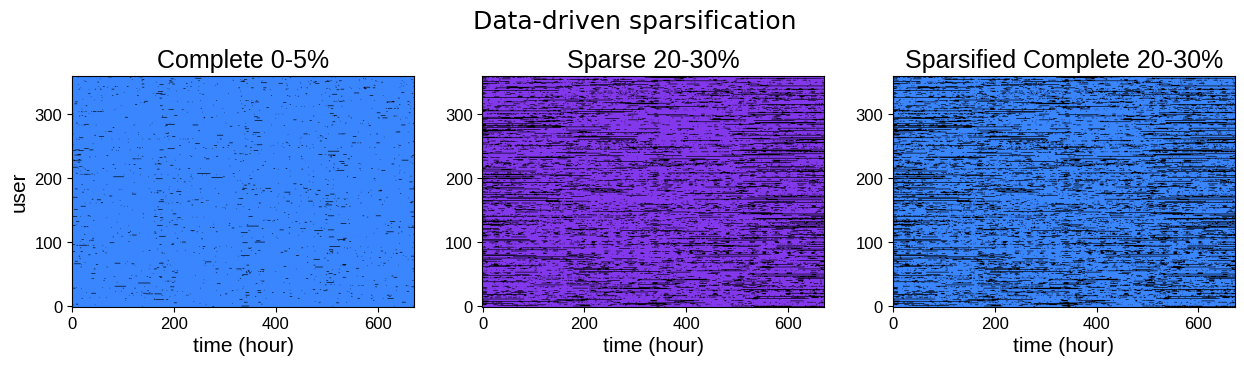

In [11]:
Levels = config.Levels

level = Levels[1]
mask_l = gen_mask(level, 
                  df_seq,
                  df_seq_complete)

mask_l = mask_l.loc[df_seq_complete.index]
df_seq_complete_sparsified = mask_l*df_seq_complete

fig, axes = plt.subplots(figsize = (15,3), ncols = 3)

HRIs = [df_seq_complete.values,
         mask_l.values,
         df_seq_complete_sparsified.values]

Colors = [config.COLOR_GT, 
          config.COLOR_BS, 
          config.COLOR_GT]

Titles = ['Complete 0-5%', 
          f'Sparse {config.DICT_rename_levels[level]}%', 
          f'Sparsified Complete {config.DICT_rename_levels[level]}%']

for ax, hri, color, title in zip(axes, HRIs, Colors, Titles):
    visual_imshow(ax, hri, ['black', color])
    ax.set_xlabel('time (hour)')
    axes[0].set_ylabel('user')
    ax.set_title(title)
    restyle_ax(ax)
plt.suptitle('Data-driven sparsification', size = config.ax_title_size, y= 1.1 )

__Instance of sparsification for different sparsity approaches__

In [12]:
Levels = config.Levels

level = Levels[1]
mask_l = gen_mask(level, 
                  df_seq,
                  df_seq_complete)

mask_l = mask_l.loc[df_seq_complete.index]
mask_l_random_shuffling = mask_l.apply(lambda row: pd.Series(shuffle_gaps_keep_durations(row.values)), axis=1)
mask_l_random_uniform = mask_l.apply(lambda row: pd.Series(np.random.permutation(row.values), index=row.index),axis=1)

Text(0.5, 1.1, 'Sparsification approaches: 20-30%')

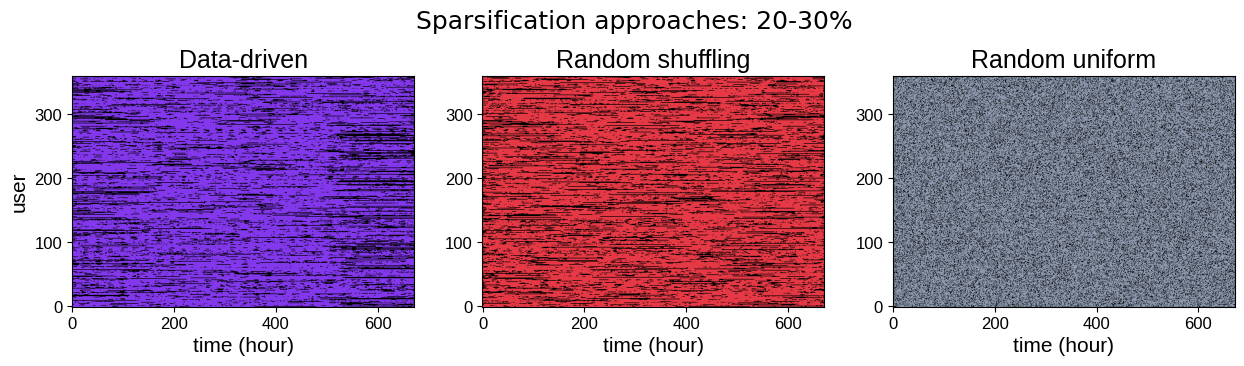

In [13]:
fig, axes = plt.subplots(figsize = (15,3), ncols = 3)

HRIs = [mask_l.values,
        mask_l_random_shuffling.values, 
        mask_l_random_uniform.values,]

Titles = ['Data-driven',
          'Random shuffling',
          'Random uniform']

Colors = [config.COLOR_BS, 
          config.COLOR_RANDOM_SHUFFLING, 
          config.COLOR_RANDOM_UNIFORM]

for ax, hri, color, title in zip(axes, HRIs, Colors, Titles):
    visual_imshow(ax, hri, ['black', color])
    ax.set_xlabel('time (hour)')
    axes[0].set_ylabel('user')
    ax.set_title(title)
    restyle_ax(ax)
    
plt.suptitle(f'Sparsification approaches: {config.DICT_rename_levels[level]}%', 
             size = config.ax_title_size, 
             y = 1.1)

#### 6.2 Stop detection and contact estimation on the complete sparsified trajectories

In [26]:
analysis.sparsification_pipeline??

Signature:
analysis.sparsification_pipeline(
    traj_complete,
    DICT_masks,
    sparsity_approach,
    level,
)
Source:   
def sparsification_pipeline(traj_complete,
                            DICT_masks,
                            sparsity_approach,
                            level):
    '''
    INPUT traj_complete dataframe 
        Consists of the complete GPS location trajectories (0-5% missing hours) during the study period 2014-2-10 to 2014-3-7
        it contains columns ['id', 'datetime', 'lat', 'lng'] 
        traj_complete : complete GPS trajectories
        DICT_masks : nested dict containing the sparsficiation masks 
            (see section 6.1 Creation of the hourly record indicator mask for sparsification)
        sparsity_approach : can take values ['Data_driven', 'Random_shuffling', 'Random_uniform']
        level : range of missing hours from config.Levels
    
    OUTPUT DICT_daily_contacts dict of type (dt.datetime, df_contact)
        for each day it assigns

In [16]:
#CODE TESTING
#Import sequence indicator
#[1] import sequence indicator
FOLD_save = config.FOLD_DTU
path_seq = f'{FOLD_save}02_df_hourly_record_indicator.csv'
df_seq = pd.read_csv(path_seq).set_index(['user_id','weekstep_index'])

In [28]:
#Import the location data for the complete users 
USERS_select = get_complete_users(df_seq)

#location data is imported by selecting a time-range which accounts for the studyperiod and a margin of 2days
#this enables to avoid undetected stops due to border effects
path = '/home/fedde/work/Project_Penn/TMP/f_005_D1_filtering/filtered_traj_1min_downsample/'
traj_complete = read_folder_files(path, 
                                  Cols_select = ['id','datetime', 'lat','lng'],
                                  parse_dates_list = ['datetime'],
                                  FILES_select = [f'{u}.csv' for u in USERS_select], 
                                  Date_range = [config.Study_period[0] - pd.Timedelta(days=2),
                                                config.Study_period[1] + pd.Timedelta(days=2)])

In [38]:
traj_complete = traj_complete.rename(columns = {'id':'user_id', 'lng':'lon'})

In [44]:
traj_complete.head(3)

,user_id,datetime,lat,lon
0,83.0,2014-02-06 00:13:00,55.763538,12.477568
1,83.0,2014-02-06 00:28:00,55.763543,12.477601
2,83.0,2014-02-06 00:43:00,55.763541,12.477574


In [ ]:
#Create the sparsification masks for different levels and sparsification approaches
Levels = config.Levels

In [19]:
DICT_masks = gen_sparsification_masks(df_seq, Levels)

In [30]:
DICT_masks.keys()

dict_keys(['Data_driven', 'Random_shuffling', 'Random_uniform'])

In [45]:
#Compute the biased contacts from the sparsified complete trajectories
DICT_daily_contacts = sparsification_pipeline(traj_complete,
                                              DICT_masks,
                                              'Data_driven',
                                              Levels[0])

2014-02-08 00:00:00
2014-02-09 00:00:00
2014-02-10 00:00:00
2014-02-11 00:00:00
2014-02-12 00:00:00
2014-02-13 00:00:00
2014-02-14 00:00:00
2014-02-15 00:00:00
2014-02-16 00:00:00
2014-02-17 00:00:00
2014-02-18 00:00:00
2014-02-19 00:00:00
2014-02-20 00:00:00
2014-02-21 00:00:00
2014-02-22 00:00:00
2014-02-23 00:00:00
2014-02-24 00:00:00
2014-02-25 00:00:00
2014-02-26 00:00:00
2014-02-27 00:00:00
2014-02-28 00:00:00
2014-03-01 00:00:00
2014-03-02 00:00:00
2014-03-03 00:00:00
2014-03-04 00:00:00
2014-03-05 00:00:00
2014-03-06 00:00:00
2014-03-07 00:00:00


In [48]:
df_contacts = pd.concat(DICT_daily_contacts.values(), axis=0)

In [49]:
df_contacts

,u1,u2,date_hour,n_minutes
0,0,165,2014-02-08 14:00:00,36
1,0,165,2014-02-08 15:00:00,60
2,0,405,2014-02-08 00:00:00,11
3,0,405,2014-02-08 01:00:00,60
4,0,405,2014-02-08 02:00:00,60
...,...,...,...,...
4635,617,641,2014-03-07 12:00:00,50
4636,666,695,2014-03-07 20:00:00,38
4637,666,695,2014-03-07 21:00:00,31
4638,666,695,2014-03-07 22:00:00,60


In [ ]:
#Import sequence indicator
path_seq = 'Pipeline_output_SYNTH/02_df_hourly_record_indicator.csv'
df_seq = pd.read_csv(path_seq).set_index(['user_id','weekstep_index'])

#Import the location data for the complete users 
USERS_select = get_complete_users(df_seq)
len(USERS_select)

#location data is imported by selecting a time-range which accounts for the studyperiod and a margin of 2days
#this enables to avoid undetected stops due to border effects

path = 'Pipeline_output_SYNTH/01_trajectories_preprocessed/'
traj_complete = read_folder_files(path, 
                                  Cols_select = ['user_id','datetime', 'lat','lon'],
                                  #parse_dates_list = ['datetime'],
                                  FILES_select = [f'{u}.csv' for u in USERS_select])
traj_complete['datetime'] = pd.to_datetime(traj_complete['datetime'], utc = True).dt.tz_localize(None)

#Create the sparsification masks for different levels and sparsification approaches
Levels = config.Levels
DICT_masks = gen_sparsification_masks(df_seq, Levels)

### 7. Contact correction - weight computation

In [52]:
analysis.compute_contact_correction_weights??

Signature:
analysis.compute_contact_correction_weights(
    df_contacts_biased,
    df_hri_sparsified,
)
Source:   
def compute_contact_correction_weights(df_contacts_biased,
                                       df_hri_sparsified):
    '''
    INPUTS 
    [1] df_contacts_biased dataframe 
    Cotains columns: ['u1', 'u2', 'date_hour', 'n_minutes']
    Each record documents a contact between user 'u1' and 'u2' during hour 'date_hour' for 'n_minutes' minutes
    
    [2] df_hri_sparsified dataframe
    hourly record indicator of the complete sparsified trajectories employied for computing df_contacts_biased
    has as columns the sequence of hours in the study period
    has index 'id'
    
    OUTPUT
    > df_contacts_biased with new columns:   
        hourofday_weekday : string indicating the hourofday (from 0 to 23) and the weekperiod (weekday or weekend)
        coverage_u1 : coverage of user 'u1' during the specific hourofday_weekday over the study period
        coverage_u2 : co

In [53]:
#CODE TESTING

#[1] COVERAGE OF SPARSE TRAJECTORIES (used for coefficient computation)
#First, import the mask used for sparsification (it should be saved over step 6.2)
#In this example, I generate a new one, to make the example
df_seq = pd.read_csv('Data_experiments/df_trajectory_record_indicator.csv', index_col = 0).set_index(['id','weekstep_index'])
DICT_masks = gen_sparsification_masks(df_seq, config.Levels)
df_mask = DICT_masks['Data_driven'][config.Levels[2]]
#then multiply the mask by the hourly record indicator of the complete users 
df_seq_w0 = df_seq[df_seq.index.get_level_values("weekstep_index") == 0].droplevel('weekstep_index')
df_seq_complete = df_seq_w0[df_seq_w0.mean(axis=1) >= 0.95]
df_seq_complete = df_seq_complete.loc[df_mask.index]
df_hri_sparsified = df_mask*df_seq_complete

#[2] IMPORT SPARSE CONTACTS
FOLD_sparse = '/home/fedde/work/Project_Penn/TMP/f01_013_D1_iter_sparsified_mask_loc_stops_contacts/'
N_si = 0
s = 'Data_driven'
l = config.Levels[4]
FOLD_save = f'{FOLD_sparse}Iter_sparse_{N_si}/{s}/{l}/'
df_cmargin_hour = pd.read_csv(FOLD_save + 'df_contact_marginal.csv')
df_cwithin_hour = pd.read_csv(FOLD_save + 'df_contact_within.csv')
df_contacts_biased = compute_tot_contacts(df_cmargin_hour, 
                                          df_cwithin_hour)

In [54]:
df_contacts_biased, coefs = compute_contact_correction_weights(df_contacts_biased,
                                                               df_hri_sparsified)

In [56]:
df_contacts_biased.head(2)

,u1,u2,date_hour,n_minutes,hourofday_weekday,coverage_u1,coverage_u2,weight
0,0,18,2014-02-18 08:00:00,9,8_weekday,0.750000,0.708333,1.882353
1,0,18,2014-02-18 09:00:00,60,9_weekday,0.666667,0.625000,2.400000


### 8. Epidemic modeling on biased and corrected contacts

#### 8.1 Calibration parameter search

In [2]:
analysis.optuna_param_search??

Signature:
analysis.optuna_param_search(
    df_contacts_biased,
    USERS_select,
    Date_range,
    N_iter,
    Curve_ref,
    GRID_stats,
    n_trials,
    show_progress_bar=True,
)
Docstring:
INPUTS 
df_contacts : dataframe of contacts [u1, u2, datetime, n_minutes]        Each record reports a contact between user 'u1' and 'u2' during hour 'date_hour' for 'n_minutes' minutes
USERS_select : list of users id in the contact dataframe
Date_range : (dt.datetime.date) array of consecutive days for running the epidemic simulation 
N_iter : number of iteration of the epidemic simulation

Curve_ref : reference curve for calibration 
    computed as the median of infected over the ensemble of groundtruth curves
    
GRID_stats : parameter boundaries 
    dataframe with columns (beta, gamma, n_init) and rows (min, max)
    
n_trials : number of trials of the optimization algorithm 

returns 
> best_params: dict with keys 'beta', 'gamma', 'seedsize'
    optimal parameters generated by the cal

In [13]:
#CODE TESTING
#consider study period for epidemic modeling (starting on Monday)
Study_period_em = [dt.datetime(2014,2,10), dt.datetime(2014,3,7)]

#IMPORT SPARSE CONTACTS
FOLD_sparse = '/home/fedde/work/Project_Penn/TMP/f01_013_D1_iter_sparsified_mask_loc_stops_contacts/'
N_si = 0
s = 'Data_driven'
l = config.Levels[4]
FOLD_save = f'{FOLD_sparse}Iter_sparse_{N_si}/{s}/{l}/'
df_cmargin_hour = pd.read_csv(FOLD_save + 'df_contact_marginal.csv')
df_cwithin_hour = pd.read_csv(FOLD_save + 'df_contact_within.csv')
df_contacts_biased = compute_tot_contacts(df_cmargin_hour, 
                                          df_cwithin_hour)

USERS_select = config.USERS_select
Date_range = pd.date_range(Study_period_em[0], Study_period_em[1]).date
N_iter = 100



#[1] Compute the reference curve for calibration
#import the ensemble of 5000 curves
with open("../Epidemic_modeling_on_sparse_GPS_trajectories/Data_experiments/groundtruth_curves.pkl", "rb") as f:
    groundtruth_curves = pickle.load(f)

#groundtruth_curves is an array of shape (5000,27,2)
#groundtruth_curves[i] is an array of shape (27,2) where:
    #the 1st column is the count of daily susceptibles over the simulation
    #the 2nd column is the count of daily infected over the simulation

#we take as reference curve the median of infected over the ensemble of simulation
Curve_ref = np.median(groundtruth_curves[:,:,1], axis = 0) 

#parameter boundaries 
df_calibration_space = pd.read_csv('Data_experiments/df_calibration_space.csv',index_col = 0)
#number of trials for optuna parameter search
n_trials = 100

study = optuna_param_search(df_contacts_biased, 
                            USERS_select,
                            Date_range, 
                            N_iter,
                            Curve_ref,
                            df_calibration_space, 
                            n_trials = n_trials,
                            show_progress_bar = True)

  0%|          | 0/100 [00:00<?, ?it/s]

In [10]:
study

({'beta': 0.005063966548886942, 'gamma': 0.4187259822587186, 'seedsize': 3},
 50.71863197711103)

#### 8.1 Oracle and Calibration modeling

In [3]:
analysis.epid_modeling??

Signature:
analysis.epid_modeling(
    df_contacts,
    USERS_select,
    Date_range,
    N_iter,
    groundtruth_params,
    modeling_type,
    Curve_ref=None,
    GRID_stats=None,
    n_trials=None,
    show_progress_bar=True,
)
Source:   
def epid_modeling(df_contacts,
                  USERS_select,
                  Date_range,
                  N_iter,
                  groundtruth_params,
                  modeling_type,
                  Curve_ref=None,
                  GRID_stats=None,
                  n_trials=None,
                  show_progress_bar=True):
    '''
    Epidemic modeling function for Oracle and Calibration workflows.

    df_contacts       : dataframe of contacts [u1, u2, date_hour, n_minutes]
    USERS_select      : list of user ids
    Date_range        : (datetime.date) array of consecutive days for the simulation
    N_iter            : number of iterations of the epidemic simulation
    groundtruth_params: dict with keys 'beta', 'gamma', 'seedsize'
   

In [7]:
#folder where the output of the analysis is stored
FOLD_output = config.FOLD_DTU
#[1] sequence indicator
path_seq = f'{FOLD_output}02_df_hourly_record_indicator.csv'
df_seq = pd.read_csv(path_seq).set_index(['user_id','weekstep_index'])
#get the list of complete users
USERS_select = analysis.get_complete_users(df_seq)


In [12]:
#load Curve_ref (median infected from groundtruth ensemble) needed by calibration
FOLD_emo = f'{FOLD_output}07_epidemic_modeling_outcomes/'
with open(f'{FOLD_emo}simulations_groundtruth.pkl', 'rb') as f:
    _epid_curves_gt = pickle.load(f)
Curve_ref = pd.Series(np.median(_epid_curves_gt[:, :, 1], axis=0))

In [9]:
#[1] study-period
_em_start = dt.datetime(2014, 2, 10)
_em_end   = dt.datetime(2014, 3, 7)
Study_period_em = [(_em_start + dt.timedelta(days=i)).date()
                   for i in range((_em_end - _em_start).days + 1)]


In [ ]:
# Single instance of calibration on sparse contacts (Data_driven, first level)
FOLD_contact_corrected = f"{config.FOLD_DTU}06_contacts_data-driven_ipw-weight/"
level  = config.Levels[0]
n_iter = 1

f_path = f"{FOLD_contact_corrected}Iter{n_iter}_Data_driven_{level}"
df_contacts = pd.read_csv(f_path)
df_contacts.head(10)

In [20]:
epid_curves, epid_metrics, best_params, best_value = analysis.epid_modeling(
    df_contacts[["u1", "u2", "date_hour", "n_minutes"]],
    USERS_select,
    Study_period_em,
    100,
    config.groundtruth_pars,
    modeling_type="Calibration",
    Curve_ref = Curve_ref,
    GRID_stats=config.GRID_stats,
    n_trials=10)

print("Best params:", best_params)

  0%|          | 0/10 [00:00<?, ?it/s]

Best params: {'beta': 0.003108158056495251, 'gamma': 0.474266835653517, 'seedsize': 1}


In [19]:
study

50.97630168356011

## Other - creating the grid of (beta,gamma) values with the underlying R0

In [2]:
config.groundtruth_pars
def grid_shift_groundtruth_gamma_daily(df_GRID_v4_sub):
        #shift the grid such that it is centered on the ground truth
        b_gt, g_gt, ni_gt = [config.groundtruth_pars[c] for c in ['beta','gamma','seedsize']] 
        G_gt = 1 - (1-g_gt)**(60*24)
        df_GRID_v4_sub['delta_beta_gt']  = df_GRID_v4_sub['beta'] - b_gt
        df_GRID_v4_sub['delta_gamma_gt'] = df_GRID_v4_sub['gamma'] - G_gt
        df_closest = df_GRID_v4_sub.query("delta_beta_gt<0 & delta_gamma_gt<0")
        df_closest = df_closest.sort_values(['delta_beta_gt','delta_gamma_gt']).iloc[-1]
        df_GRID_v4_sub['beta'] =  df_GRID_v4_sub['beta'] + abs(df_closest.loc['delta_beta_gt'])
        df_GRID_v4_sub['gamma'] = df_GRID_v4_sub['gamma'] + abs(df_closest.loc['delta_gamma_gt'])
    
        return df_GRID_v4_sub
       
#[2.2] Grid confined on the region of observed fitted parameters
Betas_v5 = np.linspace(0, 1e-2, 30)
Gammas_v5  = np.linspace(0.01, 0.9, 40)
df_GRID_v5_gamma_daily = pd.DataFrame(list(itertools.product(Betas_v5, Gammas_v5)), 
                                      columns = ['beta','gamma'])

df_GRID_v5_gamma_daily = grid_shift_groundtruth_gamma_daily(df_GRID_v5_gamma_daily)
df_GRID_v5_gamma_daily.head(2)

,beta,gamma,delta_beta_gt,delta_gamma_gt
0,0.000155,0.110000,-0.000845,-0.990000
1,0.000155,0.132821,-0.000845,-0.967179


In [4]:
#[2] ground truth contacts
FOLD_output = config.FOLD_DTU
files = glob.glob(f'{FOLD_output}04_contacts/*.csv')
df_contacts_gt = pd.concat([pd.read_csv(f, index_col=0) for f in files])
df_contacts_gt.head(2)

,u1,u2,date_hour,n_minutes
0,0,165,2014-02-09 11:00:00,25
1,0,165,2014-02-09 12:00:00,48


In [ ]:
config.F